Intercept:
34.282680960226436

Coefficients:
hours_op:2.254524332212278
ambient:2.9885102819982303
load_pct:0.6037863524285113
voltage:0.6757943712085435


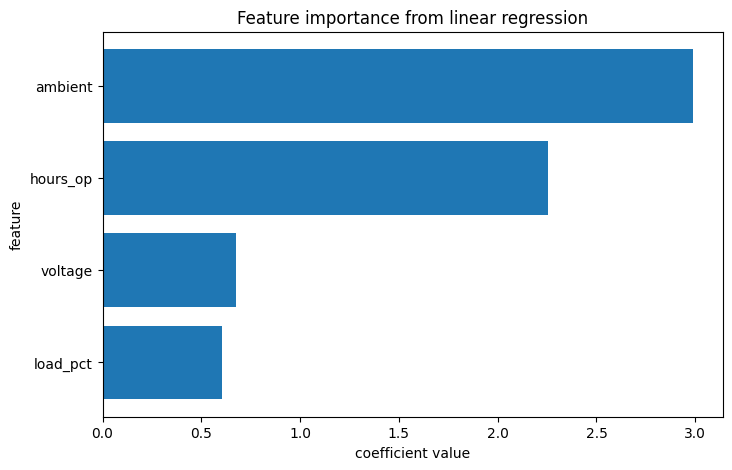

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LinearRegression
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
n = 300

hours_op = np.random.uniform(0, 10, n)
ambient = np.random.uniform(20, 40, n)
load_pct = np.random.uniform(0.2, 0.1, n)
voltage = np.random.uniform(210, 240, n)


X = np.column_stack((hours_op, ambient, load_pct, voltage))

noise = np.random.normal(0, 2, n)

y= (
    0.8 * hours_op +
    0.5 * ambient +
    25 * load_pct +
    0.05 * voltage +
    noise
)
feature_names = ["hours_op", "ambient", "load_pct", "voltage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}:{coef}")

sorted_coefs = sorted(
    zip(feature_names, model.coef_),
    key=lambda x: abs(x[1])
)

sorted_features = [x[0] for x in sorted_coefs]
sorted_values = [x[1] for x in sorted_coefs]

plt.figure(figsize=(8, 5))
plt.barh(sorted_features, sorted_values)

plt.xlabel("coefficient value")
plt.ylabel("feature")
plt.title("Feature importance from linear regression")

plt.show()


